## **PART 1 -- Inference from samples**

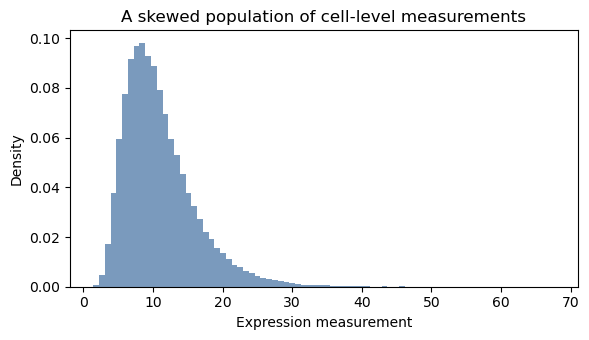

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(375)
population = rng.lognormal(mean=2.3, sigma=0.45, size=100_000)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(population, bins=80, density=True, color="#4E79A7", alpha=0.75)
ax.set_xlabel("Expression measurement")
ax.set_ylabel("Density")
ax.set_title("A skewed population of cell-level measurements")
plt.tight_layout()


#### **Question 1:** Sampling variability and confidence intervals
1. Describe the shape of the population distribution. Does it look Gaussian?
2. For each 𝑛 in sample_sizes = [5, 20, 100], draw 5,000 independent samples from population,
store their means, and plot the three sampling distributions. How do their centers and spreads
change as 𝑛 increases?
3. Explain how the simulation illustrates the Central Limit Theorem. Compare the simulated standard
deviations with 𝑠/√𝑛, and explain how standard errors change when sample size is multiplied by
four.
4. Does the Central Limit Theorem claim that individual measurements become Gaussian as 𝑛 increases?
Explain the distinction.

Use the following seven control-cell measurements to examine uncertainty in a mean:
𝑦𝐶 = (8.8, 9.6, 10.2, 10.7, 11.0, 11.4, 12.1).
5. Calculate the sample mean, sample standard deviation, estimated standard error, and an approximate 95% confidence interval using 𝑦 ± 𝑡0.975,𝑛−1 s/sqrt(n).
6. In your own words, explain what 95% confidence means for the procedure that produced this interval.
What would be an incorrect interpretation?
7. Repeat the interval calculation using a much larger simulated sample from population. Why is the
larger-sample interval generally narrower? Name two other factors that affect interval width, and
distinguish uncertainty in the mean from variability among observations.

The simulated standard deviation for n = 5 is 2.373 while the standard error is 2.336, a difference of 1.56%
The simulated standard deviation for n = 20 is 1.169 while the standard error is 1.168, a difference of 0.08%
The simulated standard deviation for n = 100 is 0.518 while the standard error is 0.522, a difference of 0.82%


Sample mean: 10.54
Sample standard deviation: 1.11
Estimated standard error: 0.42
The 95% confidence interval is: [9.51, 11.57]
The 95% confidence interval for a sample of 1000 from the population is: [10.50, 11.29]


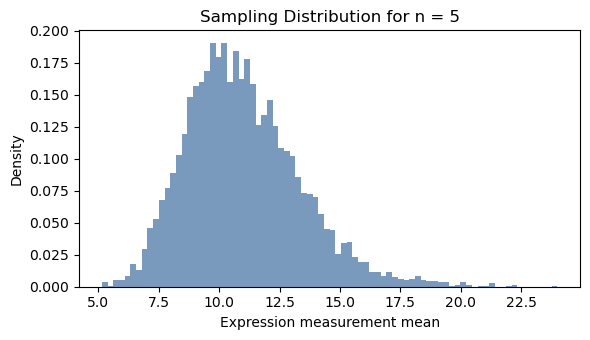

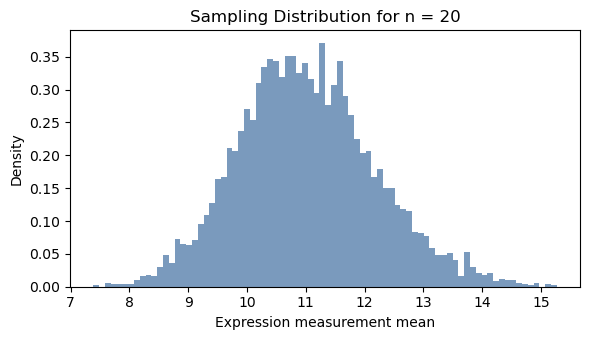

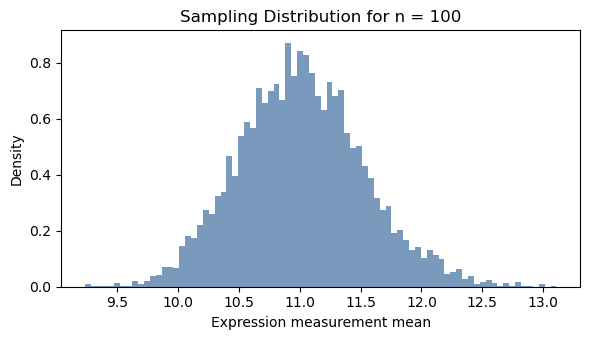

In [47]:
###
# Answers
###

#1. 
# The plot looks to unimodal and right skewed. It does not look Gaussian since Gaussian distributions are symmetric and bell-shaped, while this distrbution is not symmetric and has greater density in lower values.

#2. 
sample_sizes = [5, 20, 100]
for n in sample_sizes:

    s_means = []

    for i in range(5000):
        sample = rng.choice(population, size=n, replace=True)
        s_means.append(sample.mean())

    s_means = np.array(s_means)

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.hist(s_means, bins=80, density=True, color="#4E79A7", alpha=0.75)
    ax.set_xlabel("Expression measurement mean")
    ax.set_ylabel("Density")
    ax.set_title(f"Sampling Distribution for n = {n}")
    plt.tight_layout()
    

#As n increases, the sampling distribution moves from being closer to the distribution of the original population to being more normal. The right skewdness decreases and the center stabilizes around 11 with less variability at the tails. A more symmetric bell-shaped curve with narrower tails can be observed.

#3.
    means_std = s_means.std(ddof=1)
    pop_se = population.std(ddof=1)/np.sqrt(n)
    print(f"The simulated standard deviation for n = {n} is {means_std:.3f} while the standard error is {pop_se:.3f}, a difference of {np.abs((means_std-pop_se)/pop_se * 100):.2f}%")

#The simulation illustrates CLT because what CLT states is that as n, the number of observations in the sample, increases, the distribution of the sample means become more and more normal. In this simulation, we can see the right-skew of the original population balances and become symmetric as n increases. The rule of thumb is that n >= 30 is the typical condition for the sample mean distribution to be approximately normal, regardless of original population distribution. The percent difference between the simulated standard deviation of the means and the calculated standard error are 2.06% for n=5, 0.02% for n=20, and 1.11% for n=100. These values are very small, indicating that the two numbers are in close agreement with each other. Since the standard error approximates the variability in sample means, the close alignment suggests that this approximation is valid. When the sample size is multiplied by 4, since this factor is square rooted in the denominator, the standard errors are halved. 

#4. 
#No, the distribution of individual measurements does not change due to sample size because this distribution is still wholly dependent on the original population distribution. The Central Limit Theorem only asserts that the sample means become approximately normally distributed as n increases, not the individual measurements. In essence, individual measurements refers to single observations, which maintain their original distribution, while sample means refer to the average of a group of randomly selected observations, which does become normally distributed. 

#5.
yc = np.array([8.8, 9.6, 10.2, 10.7, 11.0, 11.4, 12.1])
print(f"\n\nSample mean: {yc.mean():.2f}")
print(f"Sample standard deviation: {yc.std(ddof=1):.2f}")
print(f"Estimated standard error: {yc.std(ddof=1)/np.sqrt(yc.size):.2f}")
t_add = 2.447*yc.std(ddof=1)/np.sqrt(yc.size)
print(f"The 95% confidence interval is: [{yc.mean() - t_add:.2f}, {yc.mean() + t_add:.2f}]")

#6.
# A 95% confidence means that 95% of the intervals that are calculated using this procedure would contain the true population mean. An incorrect interpretation is saying that this interval has a 95% probability of capturing the true population mean. 

#7.
ss = 1000
sample2 = rng.choice(population, size=ss, replace=True)
t_add = 2.447*sample2.std(ddof=1)/np.sqrt(ss)
print(f"The 95% confidence interval for a sample of 1000 from the population is: [{sample2.mean() - t_add:.2f}, {sample2.mean() + t_add:.2f}]")

#The larger-sample interval is generally narrower due to CLT as well. Since the error is dependent on the sample SEM and the critical value, maintaining the same critical value means that a smaller SEM contributes to a smaller error. We established that SEM decreases as n increases, which is why the interval also narrows. Two other factors include the critical value, which determines the confidence level of the interval, and standard deviation in the population, which affects the standard deviation in the sample. Uncertainty in the mean refers to the variability in the average of individual observations, whereas the variability in observations refers to the differences in values of those observations. A higher n decreases uncertainty in the mean but does not affect variability in observations.

#### **Question 2:** Comparing Two Groups

Treat the following as expression measurements from two independent groups:
control = np.array([9.2, 9.8, 10.0, 10.4, 10.7, 11.1, 11.5])
treated = np.array([10.1, 10.7, 11.0, 11.4, 11.6, 12.3, 12.5])
Use a plot and Welch’s two-sample 𝑡-test to compare the groups.

1. Plot the individual observations and group means. Why is it useful to show the individual observations rather than only the means?
2. Calculate the estimated difference in means, its standard error, a two-sided test statistic, a 𝑝-value, and a 95% confidence interval.
3. State the null and two-sided alternative hypotheses in terms of the population means.
4. Interpret the 𝑝-value as a probability under the null model. What does it not mean?
5. Explain why a confidence interval for the difference can be more informative than a binary “significant/not significant” label.
6. Suppose another study estimates a larger difference in means but has a much larger standard error. Could its 𝑝-value be less significant than the result here? Explain using the signal-to-noise structure of the 𝑡 statistic.
7. Why is it important to decide whether a test should be one-sided or two-sided before examining the result?

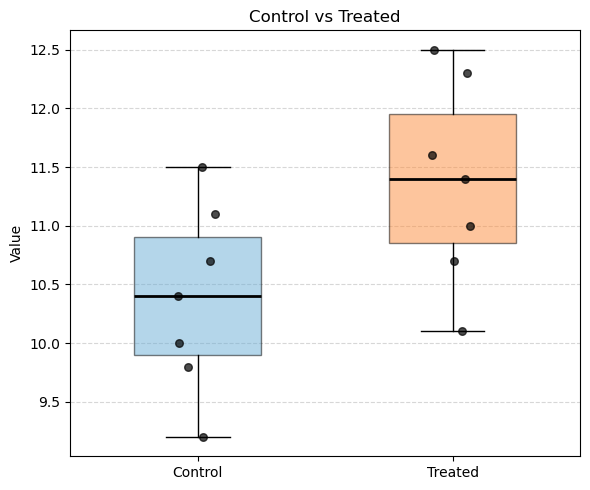

Difference in means: 0.9857
Standard error: 0.4403
t-statistic: 2.2387, df = 11.93
p-value (two-sided): 0.04504
95% CI: (0.0257, 1.9457)


In [48]:
###
# Answers
###

#1. 
control = np.array([9.2, 9.8, 10.0, 10.4, 10.7, 11.1, 11.5])
treated = np.array([10.1, 10.7, 11.0, 11.4, 11.6, 12.3, 12.5])

fig, ax = plt.subplots(figsize=(6,5))
box = ax.boxplot([control, treated], labels=['Control', 'Treated'], patch_artist=True, widths=0.5, showfliers=False)

colors = ['#6baed6', '#fd8d3c']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(2)

# Overlay individual points with a bit of horizontal jitter so they don't overlap
rng = np.random.default_rng(0)
for i, data in enumerate([control, treated], start=1):
    jitter = rng.uniform(-0.08, 0.08, size=len(data))
    ax.scatter(np.full(len(data), i) + jitter, data, color='black', alpha=0.7, zorder=3, s=30)

ax.set_ylabel('Value')
ax.set_title('Control vs Treated')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#It's useful to show the individual observations as well to qualitatively analyze the spread of the data. The means only show the average of the data, but the individual points help answer questions about the spreads of the two groups, amount of overlap in ranges, and other details. 

#2.
n1, n2 = len(control), len(treated)
m1, m2 = control.mean(), treated.mean()
v1, v2 = control.var(ddof=1), treated.var(ddof=1)

diff = m2 - m1

se = np.sqrt(v1/n1 + v2/n2)
df = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
t_stat = diff / se
p_value = 2 * stats.t.sf(np.abs(t_stat), df)
ci = (diff - stats.t.ppf(0.975, df)*se, diff + stats.t.ppf(0.975, df)*se)

print(f"Difference in means: {diff:.4f}")
print(f"Standard error: {se:.4f}")
print(f"t-statistic: {t_stat:.4f}, df = {df:.2f}")
print(f"p-value (two-sided): {p_value:.5f}")
print(f"95% CI: ({ci[0]:.4f}, {ci[1]:.4f})")

#3.
#Null: There is no difference in expression between the control and treated groups, i.e. the difference in population means is 0.
#Alternative: There is a difference in expression between the control and treated groups, i.e. the difference in population means is not 0. 

#4.
#The probability is about 0.045, meaning that assuming the null hypothesis is true, the probability of observing values as or more extreme than what was actually observed is 0.045. It does not mean that the difference in mean observed has a probability of 0.045 of being correct, or that the probability of the null being true is 0.045. It only gives you the probability of seeing the observed result or one more extreme assuming the null is true.

#5.
#A confidence interval provides a range of possible differences in mean to consider and allows you to qualitatively analyze the uncertainty in the difference in means. A wide interval would suggest that there is a lot of noise in the data, whereas a narrower one might show you that the result might have more signal. These insights cannot be extracted from a simple significance label.

#6.
#Yes, the t-statistic captures the ratio of the signal to noise. The signal is the numerator, the difference in means, while the noise is the denominator, the SE. If the difference in means increases, the t-statistic also increases. This corresponds to a lower p-value. However, if the SE also increases, depending on how much it increases, it could drive down the t-statistic and result in a higher p-value. This would make it less significant. It depends on how much the factor of the increase in difference in means relative to the factor of increase in the SE.

#7.
#Determining whether the test should be one-sided or two sided is important to avoid biases when performing the significance test and maintain test relevance. Depending on the alternative hypothesis, we could be looking for any difference in the mean or looking for a difference in a certain direction. Choosing the test to align with the alternative hypothesis is important to maintain relevance. Also, people tend to want to look for significance, so choosing after examining the results introduces a sort of confirmation bias. 

#### **Question 3:** Linear Models and Likelihood
1. Fit the model 𝑦𝑖 = 𝛽0 + 𝛽1𝑥𝑖 + 𝜀𝑖, 𝑥𝑖 = 0 for control and 𝑥𝑖 = 1 for treated. 

    What do 𝛽0 and 𝛽1 represent? Explain why testing 𝐻0 ∶ 𝛽1 = 0 asks the same scientific question as testing equal group means.

2. In one or two sentences, explain why maximizing a Gaussian likelihood with respect to 𝛽 is equivalent to minimizing
‖𝑦 − 𝑋𝛽‖22

3. Give two assumptions that make a two-sample 𝑡-test or Gaussian linear model more reliable. For each assumption, describe one possible consequence of violating it.

4. Why should a plot of the observations be part of the analysis before reporting a test statistic or 𝑝-value?

5. If the group indicator were coded as 𝑥𝑖 = 1 for control and 𝑥𝑖 = 0 for treated instead, how would the interpretations of 𝛽0 and 𝛽1 change?

6. What does a residual represent in a linear model? Give one example of a residual pattern that might suggest the model is inadequate.

In [49]:
###
# Answers
###

import statsmodels.api as sm

#1.
y = np.concatenate([control, treated])
x = np.concatenate([np.zeros(len(control)), np.ones(len(treated))])

X = sm.add_constant(x)  # adds the intercept column
model = sm.OLS(y, X).fit()
print(model.summary())

#B0 represents the mean expression in control group while B1 represents the difference in expression from the control group in the treated group. Since B1 = 0 suggests there is no difference in expression between the control group and greatment group, testing for it asks the same scientific question as testing if the group means are equal.

#2.
#The model can be written as y = Xß + ε where ε ~ N(0, Isigma^2), and since the log-likelihood can be expressed as ‖𝑦 − 𝑋𝛽‖22, maximizing with Gaussian likelihood with respect to be ß means that the y - Xß vector is minimized in magnitude.

#3.
#One assumption of the two-sample t-test is that the two groups are normally distributed. If this assumption is violated, skewdness or heavy tails can influence means and variances by introducing more extreme values. Since significance tests rely on both of these metrics to determine significance, distortion of these values can throw off calculated values for p and CI and result in false results. Another assumption is that observations are independent. If they are not, this can result in variances that are lower than they should be, which would inflate the p-value and result in false positives (rejections of the null). 

#4.
#A plot of the observations is useful in qualitatively checking if the assumptions for the test hold, and that nothing seems unusual. Skews or abnormal distributions in the observations in the sample could help catch instances of broken assumptions that would render the test results unreliable. 

#5.
#In this case, the E[y | x0] = ß0 and E[y | x1] = B0 + B1 would imply that B0 represents the mean expression in the control group while B1 would refer to the difference in mean expression between the control group and the treated group. The only difference is that the baseline being compared to is the treated expression instead of the control expression. 

#6. 
#A residual represents the difference between the value predicted by a model and the value of the actual observation. One example of a residual pattern that would suggest the model was inadequate would be if the residuals appeared to increase as the expected values themselves increased. This would suggest that the observations might be better fitted by a non-linear model instead. 

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     5.012
Date:                Sun, 13 Sep 2026   Prob (F-statistic):             0.0449
Time:                        12:00:55   Log-Likelihood:                -16.072
No. Observations:                  14   AIC:                             36.14
Df Residuals:                      12   BIC:                             37.42
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.3857      0.311     33.357      0.0

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=14
  res = hypotest_fun_out(*samples, **kwds)


## **Part 2 -- Multiple Testing and Genomic Associations**

#### **Question 4:** Type I and Type II errors and power

1. For the two-group test in Problem 2, describe a Type I error and a Type II error in the context of
treatment and expression.
2. Define statistical power as a probability. What event is the test trying to detect?
3. Use simulation to estimate the power of a two-sample test as the treated-group mean changes while
the control-group mean and sample sizes stay fixed. Plot power against the true treatment effect for
at least five effect sizes.
4. Repeat the power simulation after doubling both group sample sizes. What changes, and why?
5. Explain why lowering the significance level from 𝛼 = 0.05 to 𝛼 = 0.01 generally decreases Type I
errors but can increase Type II errors.
6. Explain why a larger effect, larger sample size, or lower measurement noise generally increases power.

Effect size = 0.00  ->  Power = 0.047
Effect size = 0.50  ->  Power = 0.170
Effect size = 1.00  ->  Power = 0.540
Effect size = 1.50  ->  Power = 0.872
Effect size = 2.00  ->  Power = 0.987
Effect size = 2.50  ->  Power = 0.999
Effect size = 3.00  ->  Power = 1.000
Effect size = 0.00  ->  Power = 0.050
Effect size = 0.50  ->  Power = 0.335
Effect size = 1.00  ->  Power = 0.871
Effect size = 1.50  ->  Power = 0.995
Effect size = 2.00  ->  Power = 1.000
Effect size = 2.50  ->  Power = 1.000
Effect size = 3.00  ->  Power = 1.000


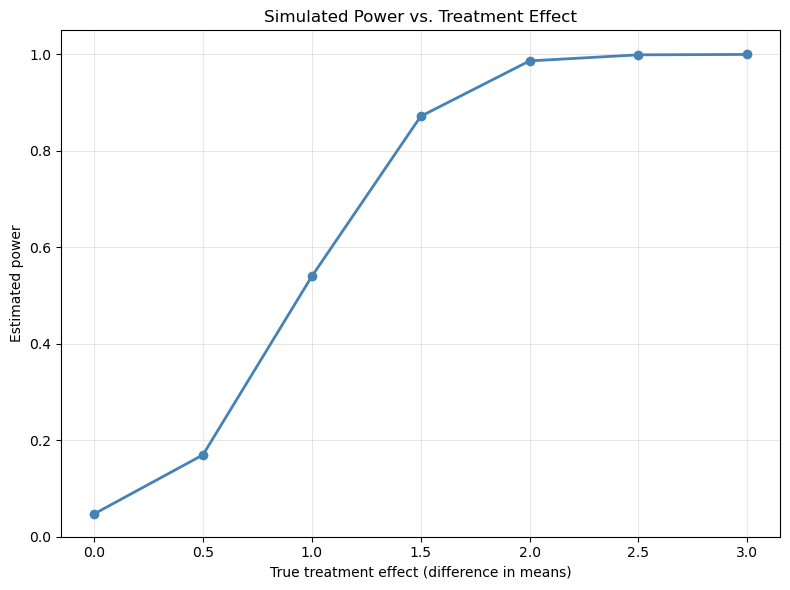

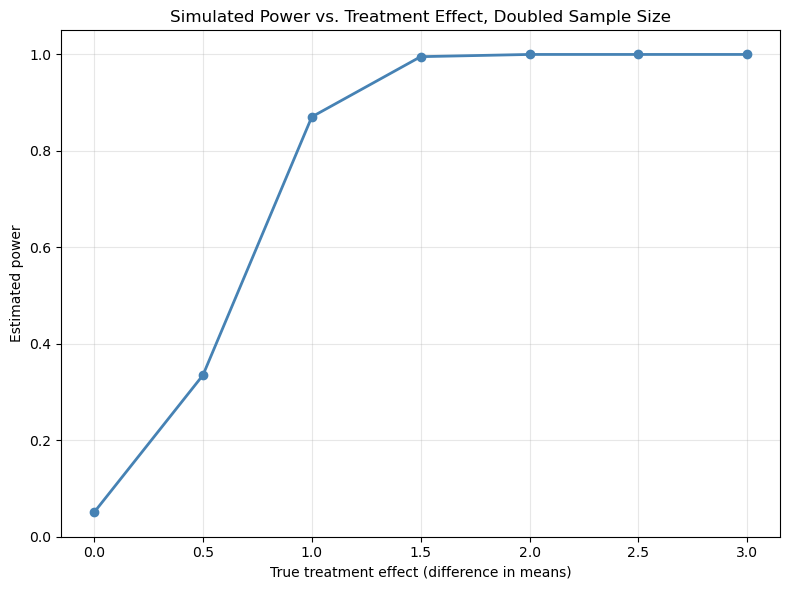

In [ ]:
###
# Answers
###

#1. 
# A Type I error refers to a false positive, meaning that the null hypothesis was rejected even though it was true. A Type II error refers to a false negative, meaning that the null hypothesis was not rejected when it was not true. In the context of treatment and expression, a Type I error would occur if the treatment does not affect expression but the test showed that it did. A Type II error would occur if the treatment did actually affect expression but the test showed that it did not. 

#2. 
# Statistic power is defined as the probability of the test rejecting the null hypothesis assuming the alternative is true. This test is trying to detect true positives, where the test shows that the null should be rejected and the alternative hypothesis does turn out to be true. 

#3. 
n_control = len(control)
n_treated = len(treated)

# Use pooled/observed standard deviations as the basis for simulation
control_mean = control.mean()
control_sd = control.std(ddof=1)
treated_sd = treated.std(ddof=1)

alpha = 0.05
n_sims = 10000

# Range of true treatment effects (mean difference: treated_mean - control_mean)
effect_sizes = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0])

rng = np.random.default_rng(12)

powers = []

for effect in effect_sizes:
    true_treated_mean = control_mean + effect
    reject_count = 0

    for i in range(n_sims):
        sim_control = rng.normal(loc=control_mean, scale=control_sd, size=n_control)
        sim_treated = rng.normal(loc=true_treated_mean, scale=treated_sd, size=n_treated)

        t_stat, p_val = stats.ttest_ind(sim_control, sim_treated, equal_var=False)

        if p_val < alpha:
            reject_count += 1

    power = reject_count / n_sims
    powers.append(power)
    print(f"Effect size = {effect:.2f}  ->  Power = {power:.3f}")

powers = np.array(powers)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(effect_sizes, powers, marker='o', linewidth=2, color='steelblue')
plt.xlabel('True treatment effect (difference in means)')
plt.ylabel('Estimated power')
plt.title('Simulated Power vs. Treatment Effect')
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()

#4.

powers = []

for effect in effect_sizes:
    true_treated_mean = control_mean + effect
    reject_count = 0

    for i in range(n_sims):
        sim_control = rng.normal(loc=control_mean, scale=control_sd, size=2*n_control)
        sim_treated = rng.normal(loc=true_treated_mean, scale=treated_sd, size=2*n_treated)

        t_stat, p_val = stats.ttest_ind(sim_control, sim_treated, equal_var=False)

        if p_val < alpha:
            reject_count += 1

    power = reject_count / n_sims
    powers.append(power)
    print(f"Effect size = {effect:.2f}  ->  Power = {power:.3f}")

powers = np.array(powers)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(effect_sizes, powers, marker='o', linewidth=2, color='steelblue')
plt.xlabel('True treatment effect (difference in means)')
plt.ylabel('Estimated power')
plt.title('Simulated Power vs. Treatment Effect, Doubled Sample Size')
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()

#The estimated power increases significantly quicker with increasing treatment effect when the sample size doubles. This is because the standard error of the two distributions becomes narrower with an increased sample size. A narrower distribution reduces the overlap between the tails, thereby improving the ability of the test to reject the null when the alternative hypothesis is true.

#5.
# Lowering the signifiance level increases the p-threshold required to reject the null. Since alpha corresponds to the probability of a false positive, the Type I errors decrease. However, the increased burden imposed by the higher necessary p-value means that the null is less likely to be rejected even if the alternative is true. Consequently, the false negative rate increases, which is associated with Type II errors. 

#6.
#Power is dependent on obtaining a high t-statistic. By increasng the effect, the signal of t increases, which also increases the t-statisitic. Increasing the sample size does the same thing by reducing noise, which increases the signal-to-noise ratio captured by t. This is done by reducing the SEM. Lower measurement noise also reduces the standard error, which then increases power by the same mechanism as the increase in sample size. 

Use this small set of 𝑝-values:
p_values = np.array([0.001, 0.008, 0.012, 0.021, 0.047, 0.18, 0.44, 0.72])

#### **5. Questions:** FWER and Bonferroni correction

1. At family-wise level 𝛼 = 0.05, which hypotheses would be rejected without correction? Which would
be rejected with the Bonferroni threshold 𝛼/𝑚?
2. Explain what FWER controls and why Bonferroni is called conservative.
3. Use the Bonferroni-adjusted values min(𝑚𝑝𝑗, 1) to produce adjusted 𝑝-values. Confirm that thresh-
olding these at 0.05 gives the same decisions as thresholding raw 𝑝-values at 0.05/𝑚.
4. Give one setting in which controlling FWER might be preferable to controlling FDR.

In [ ]:
###
#Answers
#

p_values = np.array([0.001, 0.008, 0.012, 0.021, 0.047, 0.18, 0.44, 0.72])

#1.
print(f"a/m = {0.05/len(p_values)}")
#Without correction, the hypotheses corresponding to p-values 0.001, 0.008, 0.012, 0.021, and 0.047 would all be rejected. With Bonferroni threshold a/m, only 0.001 would be rejected.

#2.
# FWER controls for the probability of any false positives across all tests. It is defined as the probability of making at least one false discovery among all m hypotheses. Bonferroni is called conservative because it controls the FWER by bounding the bulk probability of false positives at a at the most. By lowering the threshold from a to a/m, it ensures that the probability of any false positive remains at most a even though there are m tests being done. It's conservative because it imposes such a high threshold to meet to qualify as significance, making it harder for a gene with modest effect to pass the threshold with higher m-values.

#3. 
bonferroni_adj = np.minimum(p_values*len(p_values), 1)
print(bonferroni_adj)
#Only the first p-value, 0.001, still is rejected with the adjusted p-value. This matches the previous way of thresholding the p-values at 0.05/m. 

#4.
# In cases where it is astronomically expensive to do confirmatorial studies, it would be ideal to minimize false positives to the furthest extent possible. In this case, controlling the FWER would be better because it is significantly more conservative and therefore more likely to result in a few hits with a lower false positive chance. 


a/m = 0.00625
[0.008 0.064 0.096 0.168 0.376 1.    1.    1.   ]


#### **6. Questions:** False discovery rate and Benjamini–Hochberg
Apply the Benjamini–Hochberg procedure at target 𝑞 = 0.05 to p_values.

1. Sort the 𝑝-values and calculate the thresholds 𝑘𝑞/𝑚 for each rank 𝑘.
2. Find the largest rank satisfying 𝑝(𝑘) ≤ 𝑘𝑞/𝑚. Which hypotheses are discoveries?
3. Compare the Bonferroni and BH discovery lists. Explain why they can differ.
4. Define the false discovery proportion (FDP) for one dataset and the false discovery rate (FDR)
across repeated datasets. Why should we not interpret FDR as a guarantee that exactly 5% of this
particular list are false?
5. Write a short recommendation: would FWER or FDR be more appropriate for an exploratory screen
of thousands of genes, and why?

In [ ]:
###
#Answers
###

#1.
p_values = np.sort(p_values)
kqm = [0] * len(p_values)
for i in range(len(p_values)):
    kqm[i] = (i+1)*0.05/len(p_values)
print(kqm) #where k = index + 1

#2.
significant = p_values <= np.array(kqm)
if significant.any():
    largest_k = np.max(np.where(significant)[0]) + 1
else:
    largest_k = 0

print("largest k:", largest_k)
#The hypotheses associated with p-values 0.001, 0.008, 0.0012, and 0.021 are discoveries.

#3. 
# The Bonferroni list only contains 0.001, whereas the BH discovery list has 3 additional p-values. They can differ because of their tolerance for false positives. Bonferroni imposes a max false-positive rate of alpha across all tests while BH maintains that no more than q*100 percent of discoveries are false positives on average. Since the former tries to avoid any false positives while the latter tries to bound them to a maximum proportion q, the latter typically ends up being less strict and allowing for larger discovery lists.

#4. 
# The FDP for a dataset is V/R which is the ratio of the number of false positives to the number of positives. The FDR across repeated datasets is the expected fraction of discoveries that are false, which is the average of the FDPs. The FDR only guarantees the average of the FDPs but does not maintain that guarantee for individual FDPs. Since this particular list comes from one dataset, the FDP cannot be determined for certain, so it cannot be said that it is 5%. 

#5. 
#FDR would be more appropriate because FWER imposes too stringent of a threshold to obtain a valuable discovery list. With thousands of genes, m would be very high, driving the p-threshold very low for FWER. With gene effects having relatively high variance and lower effect sizes, the lowered threshold would be hard to pass. On the other hand, FDR would likely give a larger set of p-values to explore further, which would be a more useful discovery list. 

[0.00625, 0.0125, 0.018750000000000003, 0.025, 0.03125, 0.037500000000000006, 0.043750000000000004, 0.05]
largest k: 4


#### **7. Questions:** P-value Histograms and Genomic Plots

Simulate a gene-level results table containing 2,000 genes. Include a mostly-null group of 𝑝-values and a
smaller group of alternatives with 𝑝-values concentrated near zero. Also simulate a log fold change for
each gene.
rng = np.random.default_rng(375)
n_genes = 2000
n_alt = 250
p_null = rng.uniform(0, 1, n_genes - n_alt)
p_alt = rng.beta(0.35, 1, n_alt)
p_all = np.r_[p_null, p_alt]
log2_fc = rng.normal(0, 0.35, n_genes)
log2_fc[-n_alt:] += rng.choice([-1, 1], size=n_alt) * rng.uniform(0.8, 2.0, n_alt)

1. Plot a histogram of all 𝑝-values. What would a flat background represent? What does an excess
near zero suggest?
2. Create a volcano plot with log2 fold change on the horizontal axis and − log10(𝑝) on the vertical
axis. Add guide lines at | log2 FC| = 1 and 𝑝 = 0.05. Which points have both large effects and small
raw 𝑝-values?
3. Explain why points passing the raw 𝑝 < 0.05 line in a volcano plot are not automatically valid
discoveries when thousands of genes are tested.
4. List the minimum fields you would report for each gene in a defensible analysis. Include an effect
estimate, raw 𝑝-value, and multiple-testing-adjusted 𝑝-value.

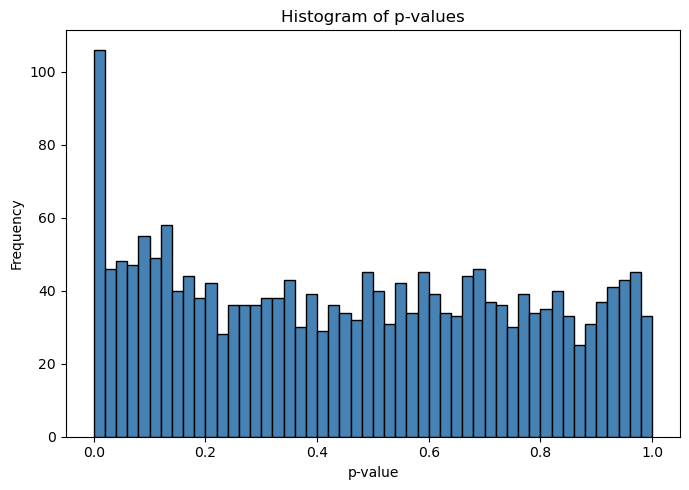

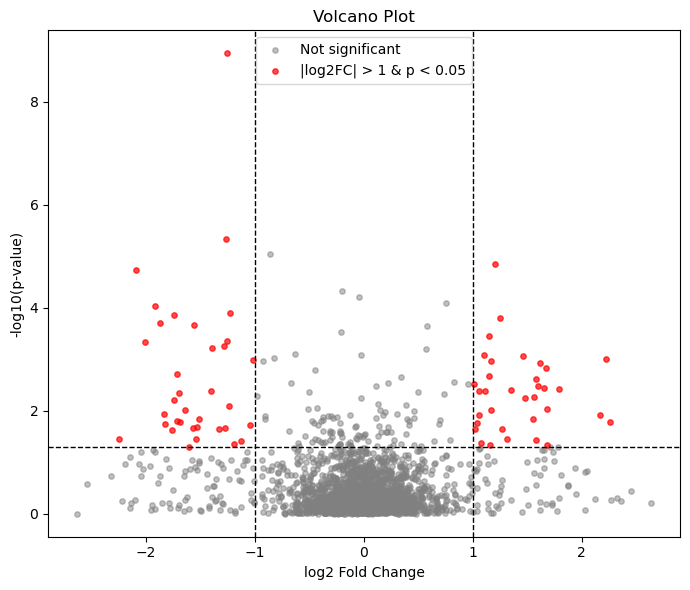

In [ ]:
###
#Answers
###

rng = np.random.default_rng(375)
n_genes = 2000
n_alt = 250
p_null = rng.uniform(0, 1, n_genes - n_alt)
p_alt = rng.beta(0.35, 1, n_alt)
p_all = np.r_[p_null, p_alt]
log2_fc = rng.normal(0, 0.35, n_genes)
log2_fc[-n_alt:] += rng.choice([-1, 1], size=n_alt) * rng.uniform(0.8, 2.0, n_alt)

#1.
plt.figure(figsize=(7, 5))
plt.hist(p_all, bins=50, edgecolor='black', color='steelblue')
plt.xlabel('p-value')
plt.ylabel('Frequency')
plt.title('Histogram of p-values')
plt.tight_layout()
plt.show()

#A flat background would represent the p-values associated with a true null distribution. An excess near zero suggests there could be real signal there, associated with p-values that might come from a true alternative distribution. 

#2.
neg_log10_p = -np.log10(p_all)

# Points with both large effect size and small raw p-value
sig_mask = (np.abs(log2_fc) > 1) & (p_all < 0.05)

plt.figure(figsize=(7, 6))
plt.scatter(log2_fc[~sig_mask], neg_log10_p[~sig_mask],
            color='gray', alpha=0.5, s=15, label='Not significant')
plt.scatter(log2_fc[sig_mask], neg_log10_p[sig_mask],
            color='red', alpha=0.7, s=15, label='|log2FC| > 1 & p < 0.05')

# Guide lines
plt.axvline(1, color='black', linestyle='--', linewidth=1)
plt.axvline(-1, color='black', linestyle='--', linewidth=1)
plt.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=1)

plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(p-value)')
plt.title('Volcano Plot')
plt.legend()
plt.tight_layout()
plt.show()

#The points in the top left and top right boxes have relatively large effects and small raw p-values.

#3.
#This is because of the multiple-testing phenomena discussed in the previous section where with thousands of genes tested, it is basically guaranteed to get some p-values that are false positives. Thus, we cannot automatically classify them as valid discoveries. 

#4.
# I would include the effect estimated transformed by log2 fold change, raw p-value from a significance test, an FDR adjusted p-value, the test statistic used, the test used, and an uncertainty on the estimate for the effect. 

## Final Synthesis

#### **8. Questions:** From data to a scientific conclusion

Choose one result from this lab and write a short paragraph addressing:
1. What scientific question were you asking?
2. What quantity did you estimate or test?
3. What did the confidence interval, 𝑝-value, or multiple-testing adjustment contribute to your conclu-
sion?
4. What uncertainty, assumption, or limitation should accompany the conclusion?
5. What additional data or analysis would make the conclusion more reliable?

#### **Answers:**

1. In section 5, we were asking what p-values were sufficiently significant to be classified as a discovery.
2. We tested the p-values against the Bonferroni threshold to determined whether we could classify them as rejected hypotheses under FWER control. 
3. As a result of the multiple-testing adjustment, we found that just one of the eight p-values were sufficiently significant to be on the discovery list. It demonstrated how controlling to maintain a maximum probability of any false positive to 5% across all tests resulted in a drastic narrowing of the list of hypotheses to reject.
4. We should keep in mind that this method of control only provides a small number of very low p-valued hypotheses, but it fails to reject hypotheses for tests that show real but only modest effects.
5. When doing many tests, choosing a different method of control like FDR would be a better idea to get a larger discovery list that could contain results from more modest effects.

#### **9. Questions:** Reflection

1. Which concept from Wednesday was most intuitive, and why?
2. Which concept from Friday was most intuitive, and why?
3. Which concept remains unclear?
4. Describe one connection between sampling variability, hypothesis testing, and multiple testing that
became clearer through the lab.

#### **Answers:**

1. The concept of a p-value was most intuitive because it was easy to understand and visually see in the area under the graph where it refers to. This made it easy to then understand its relevance in statistical tests.
2. The different types of errors, Type I and Type II, was intuitive because they had such simple and logical definitions. It was easy to grasp and understand the significance of these two errors.
3. The way two-sample tests can be written as a linear model still doesn't make sense to me. I struggle to see how everything works out to make the Beta MLE equal to the Beta OLS, and how that even relates to the difference in means. 
4. The relationship between the standard error of the mean and the standard deviation in the mean across multiple trials became a lot clearer as a result of the simulation. It was interesting to see how the two values were very similar despite that not being an intuitive conclusion to make -- associating variances from samples to a population variances with great accuracy. 